<a href="https://colab.research.google.com/github/Juli-Kareva/Fraud-detection-MDS/blob/main/Maml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 · MAML / FOMAML

Ноутбук реализует **4 конфигурации**:

| Конфиг | Алгоритм | Архитектура |
|---|---|---|
| FOMAML-S | First-Order MAML | 35→128→64→2 (LayerNorm + PReLU) |
| FOMAML-D | First-Order MAML | 35→256→128→64→2 (residual + GELU) |
| MAML-S | Full MAML (2nd order) | 35→128→64→2 (LayerNorm + PReLU) |
| MAML-D | Full MAML (2nd order) | 35→256→128→64→2 (residual + GELU) |

- Meta-train: `train_clean.csv`
- Meta-test: `Variant_I_clean.csv` … `Variant_VI_clean.csv` (адаптация на support, оценка на query)
- Ablation: inner_steps = 5 vs 10
- Итоговая таблица: FOMAML-S/D · MAML-S/D · ProtoNet-S/D · LightGBM · LogReg

---
**Структура:**
1. Установка зависимостей
2. Импорты и воспроизводимость
3. Загрузка данных и нормализация
4. EpisodeSampler (из ноутбука 03)
5. Архитектуры MAMLNet_S и MAMLNet_D
6. Вспомогательные функции (inner loop, evaluate, adapt)
7. Meta-train: общий цикл по 4 конфигурациям
8. Ablation: inner_steps 5 vs 10
9. Meta-test: финальная оценка на всех сплитах
10. Итоговая сравнительная таблица и визуализация

## 1. Установка зависимостей

In [1]:
# higher — differentiable optimization, нужна для full MAML (second-order gradients)
!pip install higher -q

import subprocess
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
                        capture_output=True, text=True)
gpu_info = result.stdout.strip() if result.returncode == 0 else 'не найден — Runtime → Change runtime type → GPU'
print(f'GPU: {gpu_info}')

GPU: Tesla T4, 15360 MiB


## 2. Импорты и воспроизводимость

In [2]:
import os, copy, random, pickle, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import higher
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
import warnings
warnings.filterwarnings('ignore')

# ── Воспроизводимость ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {DEVICE}')

Устройство: cuda


## 3. Загрузка данных и нормализация

Ожидаются файлы в `/content/`:
`train_clean.csv`, `test_clean.csv`, `oot_clean.csv`,
`Variant_I_clean.csv` … `Variant_VI_clean.csv`, `scaler_baseline.pkl`

In [3]:
DATA_DIR = '/content/'

train_df = pd.read_csv(os.path.join(DATA_DIR, 'df_train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'df_test.csv'))
oot_df   = pd.read_csv(os.path.join(DATA_DIR, 'df_oot.csv'))

VARIANT_NAMES = ['I', 'II', 'III', 'IV', 'V']

variants = {}
for v in VARIANT_NAMES:
    variants[v] = pd.read_csv(os.path.join(DATA_DIR, f'{DATA_DIR}Variant {v}.csv'))

In [4]:
FEATURES = [
    'name_email_similarity', 'session_length_in_minutes', 'zip_count_4w',
    'velocity_6h', 'credit_risk_score', 'zip_count_4w_clean',
    'current_address_months_count_clean', 'date_of_birth_distinct_emails_4w',
    'bank_branch_count_8w_clean', 'bank_months_count', 'income',
    'proposed_credit_limit', 'customer_age', 'device_os_windows',
    'email_is_free', 'phone_home_valid', 'keep_alive_session',
    'phone_mobile_valid', 'housing_status_BC', 'payment_type_AB',
    'payment_type_AC', 'housing_status_BB', 'foreign_request',
    'payment_type_AD', 'has_other_cards', 'prev_address_months_count_clean',
    'employment_status_CB', 'employment_status_CC', 'device_os_other',
    'device_os_macintosh', 'housing_status_BE', 'housing_status_BD',
    'source_TELEAPP', 'employment_status_CD', 'device_os_x11'
]

TARGET = 'fraud_bool'
N_FEAT = len(FEATURES)

nan_cols = train_df[FEATURES].isnull().sum()
nan_cols = nan_cols[nan_cols > 0].sort_values(ascending=False)
print('Признаки с NaN в train_clean:')
print(nan_cols)

Признаки с NaN в train_clean:
prev_address_months_count_clean       469907
current_address_months_count_clean      2827
velocity_6h                                9
dtype: int64


In [5]:
FILL_MINUS1 = ['prev_address_months_count_clean']
FILL_MEDIAN  = ['current_address_months_count_clean', 'velocity_6h']

# Считаем медианы по train
medians = train_df[FILL_MEDIAN].median()
print('Медианы по train:')
print(medians)

def fix_nan(df):
    df = df.copy()
    for col in FILL_MINUS1:
        if col in df.columns:
            df[col] = df[col].fillna(-1)
    for col in FILL_MEDIAN:
        if col in df.columns:
            df[col] = df[col].fillna(medians[col])
    return df

train_df = fix_nan(train_df)
test_df  = fix_nan(test_df)
oot_df   = fix_nan(oot_df)
variants = {name: fix_nan(df) for name, df in variants.items()}

# Проверка
remaining = train_df[FEATURES].isnull().sum().sum()
print(f'\nNaN в train после дочистки: {remaining}')

import joblib

scaler = joblib.load(os.path.join(DATA_DIR, 'scaler_baseline.pkl'))

X_train_sc    = scaler.transform(train_df[FEATURES].values).astype(np.float32)
X_test_sc     = scaler.transform(test_df[FEATURES].values).astype(np.float32)
X_oot_sc      = scaler.transform(oot_df[FEATURES].values).astype(np.float32)
variants_sc = {name: scaler.transform(df[FEATURES].values).astype(np.float32) for name, df in variants.items()}

y_train    = train_df[TARGET].values
y_test     = test_df[TARGET].values
y_oot      = oot_df[TARGET].values
y_variants = {name: df[TARGET].values for name, df in variants.items()}

# The variable `X_train` is not defined in this scope but was used in the original notebook.
# Assuming it was meant to refer to a scaled version, or is a leftover from previous iteration.
# The primary scaled data should now be `X_train_sc` which is `float32`.
# The line below would cause an error if X_train isn't globally available or defined earlier.
# For robustness, we can check X_train_sc instead.
print('NaN в X_train_sc:', np.isnan(X_train_sc).any())

Медианы по train:
current_address_months_count_clean      48.00000
velocity_6h                           6274.67205
dtype: float64

NaN в train после дочистки: 0
NaN в X_train_sc: False


In [6]:
# The following code is commented out as its functionality for type casting is moved to cell Simuj5QspMMa
# and it re-processes data using potentially incorrect variable references (X_train, variants_raw).
# import joblib

# scaler = joblib.load(os.path.join(DATA_DIR, 'scaler_baseline.pkl'))

# X_train_sc = scaler.transform(X_train).astype(np.float32)
# X_test_sc  = scaler.transform(X_test).astype(np.float32)
# X_oot_sc   = scaler.transform(X_oot).astype(np.float32)
# variants_sc = {k: (scaler.transform(Xv).astype(np.float32), yv)
#                for k, (Xv, yv) in variants_raw.items()}

# print('Нормализация применена.')

## 4. EpisodeSampler (из ноутбука 03)

Формирует мини-задачи для meta-train:
- **support set** — K примеров каждого класса → inner loop MAML
- **query set** — примеры для outer loss

In [7]:
class EpisodeSampler:
    """
    Семплер эпизодов для мета-обучения на несбалансированных данных.
    Идентичен классу из ноутбука 03 — скопирован без изменений.
    """
    def __init__(self, X, y, n_way=2, k_support=10, n_query=50, seed=42):
        self.rng       = np.random.RandomState(seed)
        self.n_way     = n_way
        self.k_support = k_support
        self.n_query   = n_query
        self.class_idx = {c: np.where(y == c)[0] for c in np.unique(y)}
        self.X = X
        self.y = y

    def sample_episode(self):
        sup_X, sup_y, qry_X, qry_y = [], [], [], []
        for c in range(self.n_way):
            idx = self.class_idx[c].copy()
            self.rng.shuffle(idx)
            n_needed = self.k_support + self.n_query // self.n_way
            if len(idx) < n_needed:
                idx = np.tile(idx, n_needed // len(idx) + 1)[:n_needed]
            s_idx = idx[:self.k_support]
            q_idx = idx[self.k_support: self.k_support + self.n_query // self.n_way]
            sup_X.append(self.X[s_idx])
            sup_y.extend([c] * self.k_support)
            qry_X.append(self.X[q_idx])
            qry_y.extend([c] * (self.n_query // self.n_way))
        return (np.concatenate(sup_X), np.array(sup_y, dtype=np.int64),
                np.concatenate(qry_X), np.array(qry_y, dtype=np.int64))

    def to_tensors(self, sX, sy, qX, qy):
        return (torch.tensor(sX).to(DEVICE), torch.tensor(sy).to(DEVICE),
                torch.tensor(qX).to(DEVICE), torch.tensor(qy).to(DEVICE))


K_SUPPORT = 10
N_QUERY   = 50
sampler = EpisodeSampler(X_train_sc, y_train, n_way=2,
                         k_support=K_SUPPORT, n_query=N_QUERY)

sX, sy, qX, qy = sampler.sample_episode()
print(f'Support: {sX.shape}, классы={dict(zip(*np.unique(sy, return_counts=True)))}')
print(f'Query:   {qX.shape}, классы={dict(zip(*np.unique(qy, return_counts=True)))}')

Support: (20, 35), классы={np.int64(0): np.int64(10), np.int64(1): np.int64(10)}
Query:   (50, 35), классы={np.int64(0): np.int64(25), np.int64(1): np.int64(25)}


## 5. Архитектуры: MAMLNet_S и MAMLNet_D

**MAMLNet_S** — зеркало EncoderMLP_S_v2 (nb03), классификационная голова вместо L2-нормы:  
`35 → 128 → 64 → 2` · LayerNorm + PReLU + Dropout

**MAMLNet_D** — зеркало EncoderMLP_D_v2 (nb03):  
`35 → 256 → residual(256) → 128 → residual(128) → 64 → 2` · GELU + Dropout

In [8]:
class MAMLNet_S(nn.Module):
    """
    Simple MLP: 35 → 128 → 64 → 2
    LayerNorm + PReLU + Dropout — зеркало EncoderMLP_S_v2 без L2-нормы.
    """
    def __init__(self, input_dim=35, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.LayerNorm(128), nn.PReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),        nn.LayerNorm(64),  nn.PReLU(), nn.Dropout(dropout),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        return self.net(x)


class ResidualBlock(nn.Module):
    """Pre-activation residual block с GELU."""
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim), nn.LayerNorm(dim), nn.GELU(),
            nn.Linear(dim, dim), nn.LayerNorm(dim),
        )

    def forward(self, x):
        return F.gelu(x + self.block(x))


class MAMLNet_D(nn.Module):
    """
    Deep MLP: 35 → 256 → res(256) → 128 → res(128) → 64 → 2
    Residual blocks + GELU — зеркало EncoderMLP_D_v2 без L2-нормы.
    """
    def __init__(self, input_dim=35, dropout=0.2):
        super().__init__()
        self.stem  = nn.Sequential(nn.Linear(input_dim, 256), nn.LayerNorm(256), nn.GELU())
        self.res1  = ResidualBlock(256)
        self.proj1 = nn.Sequential(nn.Linear(256, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout))
        self.res2  = ResidualBlock(128)
        self.proj2 = nn.Sequential(nn.Linear(128, 64),  nn.LayerNorm(64),  nn.GELU(), nn.Dropout(dropout))
        self.head  = nn.Linear(64, 2)

    def forward(self, x):
        x = self.stem(x)
        x = self.res1(x)
        x = self.proj1(x)
        x = self.res2(x)
        x = self.proj2(x)
        return self.head(x)


# Проверка форм и подсчёт параметров
_x = torch.randn(8, 35).to(DEVICE)
for NetCls in [MAMLNet_S, MAMLNet_D]:
    _m = NetCls().to(DEVICE)
    n_params = sum(p.numel() for p in _m.parameters())
    print(f'{NetCls.__name__}: out={_m(_x).shape}, params={n_params:,}')
del _x

# Класс-веса для несбалансированных данных (fit на train)
def class_weights(y):
    counts = np.bincount(y).astype(np.float32)
    w = len(y) / (len(counts) * counts)
    return torch.tensor(w).to(DEVICE)

CW = class_weights(y_train)
print(f'\nКласс-веса: не-фрод={CW[0]:.3f}, фрод={CW[1]:.3f}')

# Словарь «имя → класс сети» для итерации в meta-train
NET_REGISTRY = {'S': MAMLNet_S, 'D': MAMLNet_D}

MAMLNet_S: out=torch.Size([8, 2]), params=13,380
MAMLNet_D: out=torch.Size([8, 2]), params=217,538

Класс-веса: не-фрод=0.505, фрод=50.124


## 6. Вспомогательные функции

In [9]:
# Функции потерь
CRITERION       = nn.CrossEntropyLoss(weight=CW)  # meta-train (с class-weights)
CRITERION_PLAIN = nn.CrossEntropyLoss()            # meta-test адаптация (без весов)


def fomaml_inner_loop(model, sup_X, sup_y, inner_lr, inner_steps):
    """
    FOMAML inner loop.
    Обычный SGD без сохранения графа вычислений (первый порядок).
    Возвращает адаптированную копию модели.
    Outer gradient берётся от этой копии — это и есть FOMAML-приближение (∂θ'/∂θ ≈ I).
    """
    adapted = copy.deepcopy(model)
    opt     = torch.optim.SGD(adapted.parameters(), lr=inner_lr)
    adapted.train()
    for _ in range(inner_steps):
        loss = CRITERION(adapted(sup_X), sup_y)
        opt.zero_grad()
        loss.backward()
        opt.step()
    return adapted


@torch.no_grad()
def evaluate_model(model, X_np, y_np, threshold=0.5):
    model.eval()
    logits = model(torch.tensor(X_np).to(DEVICE)).cpu()

    # ── Патч 2: заменяем inf/nan в логитах перед softmax ─────────────────────
    logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)

    probs = torch.softmax(logits, dim=1).numpy()[:, 1]
    preds = (probs >= threshold).astype(int)
    return {
        'ROC-AUC': round(roc_auc_score(y_np, probs), 4),
        'PR-AUC':  round(average_precision_score(y_np, probs), 4),
        'F1':      round(f1_score(y_np, preds, zero_division=0), 4),
    }


def adapt_and_evaluate(base_model, X_var, y_var,
                        inner_lr, inner_steps, k_support=10, seed=42):
    rng = np.random.RandomState(seed)
    sup_idx, qry_idx = [], []
    for c in [0, 1]:
        idx = np.where(y_var == c)[0].copy()
        rng.shuffle(idx)
        n_sup = min(k_support, len(idx) // 2)
        # ── Патч 3: если класс совсем пустой — пропускаем ────────────────────
        if n_sup == 0:
            qry_idx.extend(idx.tolist())
            continue
        sup_idx.extend(idx[:n_sup].tolist())
        qry_idx.extend(idx[n_sup:].tolist())

    # Если support пустой целиком — оцениваем без адаптации
    if len(sup_idx) == 0:
        return evaluate_model(base_model, X_var[qry_idx], y_var[qry_idx])

    X_sup, y_sup = X_var[sup_idx], y_var[sup_idx]
    X_qry, y_qry = X_var[qry_idx], y_var[qry_idx]

    adapted = copy.deepcopy(base_model)
    adapted.train()
    opt    = torch.optim.SGD(adapted.parameters(), lr=inner_lr)
    sup_Xt = torch.tensor(X_sup).to(DEVICE)
    sup_yt = torch.tensor(y_sup).to(DEVICE)

    for _ in range(inner_steps):
        loss = CRITERION_PLAIN(adapted(sup_Xt), sup_yt)
        opt.zero_grad()
        loss.backward()
        # ── Патч 1: clip градиентов — предотвращает взрыв в inner loop ────────
        torch.nn.utils.clip_grad_norm_(adapted.parameters(), max_norm=5.0)
        opt.step()

    return evaluate_model(adapted, X_qry, y_qry)


print('Вспомогательные функции определены.')

Вспомогательные функции определены.


## 7. Meta-train: общий цикл по 4 конфигурациям

Обучаем все 4 модели последовательно в одном цикле.

**FOMAML:**
```
θ' = θ − α·∇L_support(θ)        # inner: обычный SGD (копия)
θ  = θ − β·∇_{θ'} L_query(θ')   # outer: Adam, первый порядок (∂θ'/∂θ ≈ I)
```
**MAML (full second-order через `higher`):**
```
θ' = θ − α·∇L_support(θ)        # inner: SGD с сохранённым графом
θ  = θ − β·∇_θ L_query(θ')      # outer: Adam, второй порядок (∂²L/∂θ² учитывается)
```

In [10]:
# ── Гиперпараметры (пересмотрены для стабильности) ───────────────────────────
META_LR           = 1e-4    # было 3e-4 — снижаем, outer Adam чувствителен к NaN
INNER_LR          = 1e-3    # было 0.01 — главная причина взрыва, снижаем в 10×
INNER_STEPS_TRAIN = 3       # было 5 — меньше шагов = меньше накопление ошибки
N_EPISODES        = 3000
LOG_EVERY         = 500
MAX_GRAD_NORM     = 2.0     # clip для outer loop

CONFIGS = [
    ('FOMAML-S', 'S', 'fomaml'),
    ('FOMAML-D', 'D', 'fomaml'),
    ('MAML-S',   'S', 'maml'),
    ('MAML-D',   'D', 'maml'),
]

trained_models = {}
train_curves   = {}

for cfg_name, net_key, algo in CONFIGS:
    NetClass = NET_REGISTRY[net_key]
    print(f'\n{"="*60}')
    print(f'  {cfg_name}  |  алгоритм={algo}  |  сеть={NetClass.__name__}')
    print(f'{"="*60}')
    t0 = time.time()

    model    = NetClass(input_dim=N_FEAT).to(DEVICE)
    meta_opt = torch.optim.Adam(model.parameters(), lr=META_LR)
    losses   = []
    nan_count = 0  # счётчик пропущенных эпизодов

    for ep in range(1, N_EPISODES + 1):
        sX_np, sy_np, qX_np, qy_np = sampler.sample_episode()
        sup_X, sup_y, qry_X, qry_y = sampler.to_tensors(sX_np, sy_np, qX_np, qy_np)

        if algo == 'fomaml':
            # ── FOMAML: inner loop с clip ──────────────────────────────────────
            adapted = copy.deepcopy(model)
            opt_inner = torch.optim.SGD(adapted.parameters(), lr=INNER_LR)
            adapted.train()
            for _ in range(INNER_STEPS_TRAIN):
                loss_inner = CRITERION(adapted(sup_X), sup_y)
                opt_inner.zero_grad()
                loss_inner.backward()
                torch.nn.utils.clip_grad_norm_(adapted.parameters(), MAX_GRAD_NORM)
                opt_inner.step()

            adapted.train()
            outer_loss = CRITERION(adapted(qry_X), qry_y)

            # ── Пропускаем эпизод если loss=NaN ───────────────────────────────
            if torch.isnan(outer_loss) or torch.isinf(outer_loss):
                nan_count += 1
                continue

            meta_opt.zero_grad()
            outer_loss.backward()
            for p_orig, p_ad in zip(model.parameters(), adapted.parameters()):
                p_orig.grad = (p_ad.grad.clone() if p_ad.grad is not None
                               else torch.zeros_like(p_orig))
            # ── Clip outer gradients ───────────────────────────────────────────
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            meta_opt.step()

        else:  # maml
            meta_opt.zero_grad()
            inner_opt = torch.optim.SGD(model.parameters(), lr=INNER_LR)
            try:
                with higher.innerloop_ctx(model, inner_opt,
                                           copy_initial_weights=False) as (fmodel, diffopt):
                    for _ in range(INNER_STEPS_TRAIN):
                        l = CRITERION(fmodel(sup_X), sup_y)
                        diffopt.step(l)
                    outer_loss = CRITERION(fmodel(qry_X), qry_y)

                if torch.isnan(outer_loss) or torch.isinf(outer_loss):
                    nan_count += 1
                    continue

                outer_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                meta_opt.step()

            except RuntimeError as e:
                # higher иногда падает при NaN в графе — пропускаем эпизод
                nan_count += 1
                continue

        losses.append(outer_loss.item())

        if ep % LOG_EVERY == 0:
            avg     = np.mean(losses[-LOG_EVERY:]) if losses else float('nan')
            elapsed = time.time() - t0
            print(f'  ep {ep:4d}/{N_EPISODES} | loss={avg:.4f} | '
                  f'пропущено={nan_count} | {elapsed:.0f}s')

    trained_models[cfg_name] = model
    train_curves[cfg_name]   = losses

    # ── Диагностика весов после обучения ──────────────────────────────────────
    has_nan = any(torch.isnan(p).any() for p in model.parameters())
    has_inf = any(torch.isinf(p).any() for p in model.parameters())
    print(f'  Веса: NaN={has_nan}, Inf={has_inf}, пропущено эпизодов={nan_count}')

    ckpt = f'/content/{cfg_name.lower().replace("-","_")}_checkpoint.pt'
    torch.save(model.state_dict(), ckpt)
    print(f'  Чекпоинт: {ckpt}')

print('\nВсе 4 конфигурации обучены.')


  FOMAML-S  |  алгоритм=fomaml  |  сеть=MAMLNet_S
  ep  500/3000 | loss=0.1003 | пропущено=0 | 19s
  ep 1000/3000 | loss=0.0497 | пропущено=0 | 31s
  ep 1500/3000 | loss=0.0477 | пропущено=0 | 43s
  ep 2000/3000 | loss=0.0465 | пропущено=0 | 54s
  ep 2500/3000 | loss=0.0458 | пропущено=0 | 66s
  ep 3000/3000 | loss=0.0455 | пропущено=0 | 78s
  Веса: NaN=False, Inf=False, пропущено эпизодов=0
  Чекпоинт: /content/fomaml_s_checkpoint.pt

  FOMAML-D  |  алгоритм=fomaml  |  сеть=MAMLNet_D
  ep  500/3000 | loss=0.0741 | пропущено=0 | 16s
  ep 1000/3000 | loss=0.0475 | пропущено=0 | 32s
  ep 1500/3000 | loss=0.0439 | пропущено=0 | 48s
  ep 2000/3000 | loss=0.0409 | пропущено=0 | 64s
  ep 2500/3000 | loss=0.0378 | пропущено=0 | 80s
  ep 3000/3000 | loss=0.0366 | пропущено=0 | 96s
  Веса: NaN=False, Inf=False, пропущено эпизодов=0
  Чекпоинт: /content/fomaml_d_checkpoint.pt

  MAML-S  |  алгоритм=maml  |  сеть=MAMLNet_S
  ep  500/3000 | loss=0.1074 | пропущено=0 | 18s
  ep 1000/3000 | loss=0.

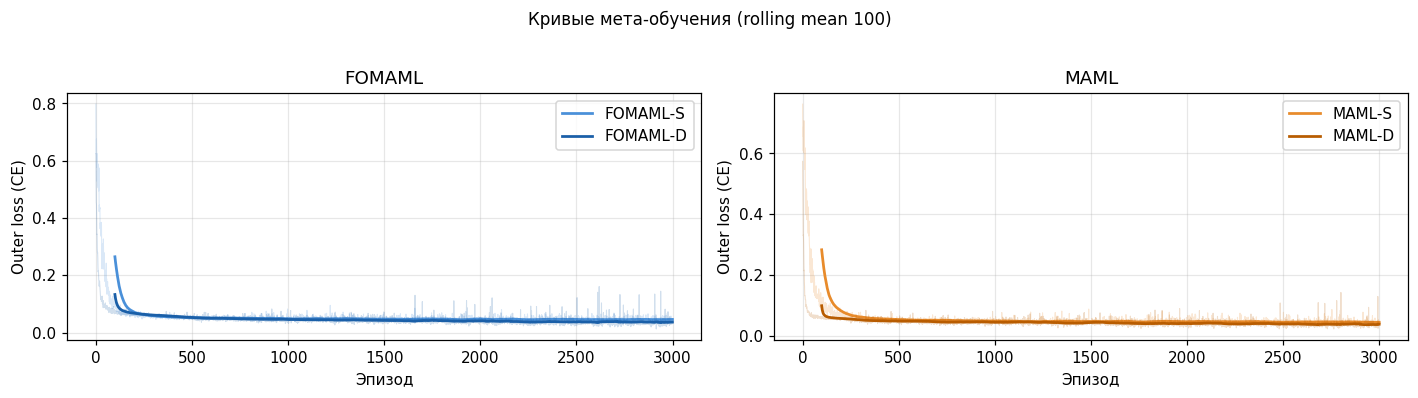

In [11]:
# ── Кривые мета-обучения: FOMAML vs MAML, S vs D ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
COLORS = {
    'FOMAML-S': '#4a90d9', 'FOMAML-D': '#1a5fa8',
    'MAML-S':   '#E88B2B', 'MAML-D':   '#b85c00',
}
WINDOW = 100

for ax, group in zip(axes, [['FOMAML-S', 'FOMAML-D'], ['MAML-S', 'MAML-D']]):
    for cfg in group:
        raw = train_curves[cfg]
        sm  = pd.Series(raw).rolling(WINDOW).mean()
        ax.plot(raw, alpha=0.2, color=COLORS[cfg], linewidth=0.7)
        ax.plot(sm,  color=COLORS[cfg], linewidth=1.8, label=cfg)
    ax.set_xlabel('Эпизод')
    ax.set_ylabel('Outer loss (CE)')
    ax.set_title(group[0].split('-')[0])
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Кривые мета-обучения (rolling mean 100)', y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig('/content/train_curves_all.png', dpi=120, bbox_inches='tight')
plt.show()

## 8.5. Hyperparameter Search (Random Search Example)

Let's perform a simple random search for one of the configurations (e.g., `MAML-D`) to find potentially better hyperparameters. This will involve trying different combinations of `META_LR`, `INNER_LR`, and `INNER_STEPS_TRAIN` and evaluating their `mean PR-AUC` on the `Variants`.

**Note:** For a full-scale hyperparameter optimization, you might consider tools like `optuna`, `hyperopt`, or `Ray Tune`, and run more trials with larger ranges and higher `N_EPISODES`.

In [ ]:
import itertools

# Define the search space for key hyperparameters
search_params = {
    'META_LR': [1e-5, 5e-5, 1e-4, 5e-4],
    'INNER_LR': [1e-4, 5e-4, 1e-3, 5e-3],
    'INNER_STEPS_TRAIN': [3, 5, 7, 10]
}

# Number of random trials for the search
NUM_TRIALS = 20

# Reduced number of episodes for faster search during hyperparameter tuning
N_EPISODES_SEARCH = 1000

best_pr_auc = -1
best_params = None
search_results = []

print(f'Starting random search for MAML-D with {NUM_TRIALS} trials...')

# Get the MAML-D configuration for search
cfg_name, net_key, algo = ('MAML-D', 'D', 'maml')
NetClass = NET_REGISTRY[net_key]

# Generate random combinations of hyperparameters
all_param_combinations = list(itertools.product(*search_params.values()))
random_combinations = random.sample(all_param_combinations, min(NUM_TRIALS, len(all_param_combinations)))

for i, combo in enumerate(random_combinations):
    current_params = dict(zip(search_params.keys(), combo))
    print(f'\n--- Trial {i+1}/{len(random_combinations)}: {current_params}')

    model_search = NetClass(input_dim=N_FEAT).to(DEVICE)
    meta_opt_search = torch.optim.Adam(model_search.parameters(), lr=current_params['META_LR'])
    losses_search = []
    nan_count_search = 0

    # Training loop for the current trial
    for ep in range(1, N_EPISODES_SEARCH + 1):
        sX_np, sy_np, qX_np, qy_np = sampler.sample_episode()
        sup_X = torch.tensor(sX_np, dtype=torch.float32).to(DEVICE)
        sup_y = torch.tensor(sy_np, dtype=torch.long).to(DEVICE)
        qry_X = torch.tensor(qX_np, dtype=torch.float32).to(DEVICE)
        qry_y = torch.tensor(qy_np, dtype=torch.long).to(DEVICE)

        if algo == 'fomaml': # This block will be skipped for MAML-D (algo='maml')
            # FOMAML logic - not needed for MAML-D search
            pass
        else:  # maml
            meta_opt_search.zero_grad()
            inner_opt_search = torch.optim.SGD(model_search.parameters(), lr=current_params['INNER_LR'])
            try:
                with higher.innerloop_ctx(model_search, inner_opt_search,
                                           copy_initial_weights=False) as (fmodel, diffopt):
                    for _ in range(current_params['INNER_STEPS_TRAIN']):
                        l = CRITERION(fmodel(sup_X), sup_y)
                        diffopt.step(l)
                    outer_loss = CRITERION(fmodel(qry_X), qry_y)

                if torch.isnan(outer_loss) or torch.isinf(outer_loss):
                    nan_count_search += 1
                    continue

                outer_loss.backward()
                torch.nn.utils.clip_grad_norm_(model_search.parameters(), MAX_GRAD_NORM)
                meta_opt_search.step()

            except RuntimeError as e:
                nan_count_search += 1
                continue

        losses_search.append(outer_loss.item() if not (torch.isnan(outer_loss) or torch.isinf(outer_loss)) else float('nan'))

        if ep % (N_EPISODES_SEARCH // 5) == 0:
            avg = np.mean([l for l in losses_search if not np.isnan(l)][- (N_EPISODES_SEARCH // 5):]) if losses_search else float('nan')
            print(f'  ep {ep:4d}/{N_EPISODES_SEARCH} | loss={avg:.4f} | пропущено={nan_count_search}')

    # Evaluate the trained model for this trial on all variants
    pr_list_trial = []
    for vname, Xv in variants_sc.items():
        yv = y_variants[vname]
        metrics = adapt_and_evaluate(model_search, Xv, yv,
                                     inner_lr=current_params['INNER_LR'], inner_steps=current_params['INNER_STEPS_TRAIN'])
        pr_list_trial.append(metrics['PR-AUC'])

    mean_pr_auc_trial = np.mean(pr_list_trial)
    print(f'  Mean PR-AUC on Variants: {mean_pr_auc_trial:.4f}')

    search_results.append({
        'params': current_params,
        'mean_pr_auc': mean_pr_auc_trial
    })

    if mean_pr_auc_trial > best_pr_auc:
        best_pr_auc = mean_pr_auc_trial
        best_params = current_params

print('\n====================================================')
print('Hyperparameter Search Complete')
print(f'Best Mean PR-AUC found: {best_pr_auc:.4f}')
print(f'Best Parameters: {best_params}')
print('====================================================')

Starting random search for MAML-D with 20 trials...

--- Trial 1/20: {'META_LR': 1e-05, 'INNER_LR': 0.005, 'INNER_STEPS_TRAIN': 7}
  ep  200/1000 | loss=0.1904 | пропущено=0
  ep  400/1000 | loss=0.1070 | пропущено=0
  ep  600/1000 | loss=0.0791 | пропущено=0
  ep  800/1000 | loss=0.0691 | пропущено=0
  ep 1000/1000 | loss=0.0652 | пропущено=0
  Mean PR-AUC on Variants: 0.0291

--- Trial 2/20: {'META_LR': 1e-05, 'INNER_LR': 0.0001, 'INNER_STEPS_TRAIN': 5}
  ep  200/1000 | loss=0.2045 | пропущено=0
  ep  400/1000 | loss=0.0990 | пропущено=0
  ep  600/1000 | loss=0.0799 | пропущено=0
  ep  800/1000 | loss=0.0719 | пропущено=0
  ep 1000/1000 | loss=0.0671 | пропущено=0
  Mean PR-AUC on Variants: 0.0318

--- Trial 3/20: {'META_LR': 0.0001, 'INNER_LR': 0.005, 'INNER_STEPS_TRAIN': 10}
  ep  200/1000 | loss=0.0743 | пропущено=0
  ep  400/1000 | loss=0.0518 | пропущено=0
  ep  600/1000 | loss=0.0470 | пропущено=0
  ep  800/1000 | loss=0.0462 | пропущено=0
  ep 1000/1000 | loss=0.0455 | пропуще

In [13]:
import itertools

# Define the search space for key hyperparameters
search_params = {
    'META_LR': [1e-5, 5e-5, 1e-4, 5e-4],
    'INNER_LR': [1e-4, 5e-4, 1e-3, 5e-3],
    'INNER_STEPS_TRAIN': [3, 5, 7, 10]
}

# Number of random trials for the search
NUM_TRIALS = 20

# Reduced number of episodes for faster search during hyperparameter tuning
N_EPISODES_SEARCH = 1000

best_pr_auc = -1
best_params = None
search_results = []

# Get the FOMAML-D configuration for search
cfg_name, net_key, algo = ('FOMAML-D', 'D', 'fomaml')
print(f'Starting random search for {cfg_name} with {NUM_TRIALS} trials...') # Corrected print statement

NetClass = NET_REGISTRY[net_key]

# Generate random combinations of hyperparameters
all_param_combinations = list(itertools.product(*search_params.values()))
random_combinations = random.sample(all_param_combinations, min(NUM_TRIALS, len(all_param_combinations)))

for i, combo in enumerate(random_combinations):
    current_params = dict(zip(search_params.keys(), combo))
    print(f'\n--- Trial {i+1}/{len(random_combinations)}: {current_params}')

    model_search = NetClass(input_dim=N_FEAT).to(DEVICE)
    meta_opt_search = torch.optim.Adam(model_search.parameters(), lr=current_params['META_LR'])
    losses_search = []
    nan_count_search = 0

    # Training loop for the current trial
    for ep in range(1, N_EPISODES_SEARCH + 1):
        sX_np, sy_np, qX_np, qy_np = sampler.sample_episode()
        sup_X = torch.tensor(sX_np, dtype=torch.float32).to(DEVICE)
        sup_y = torch.tensor(sy_np, dtype=torch.long).to(DEVICE)
        qry_X = torch.tensor(qX_np, dtype=torch.float32).to(DEVICE)
        qry_y = torch.tensor(qy_np, dtype=torch.long).to(DEVICE)

        if algo == 'fomaml':
            # FOMAML: inner loop with clipping (copied from cell N_Vlj-kWmFc6)
            adapted = copy.deepcopy(model_search)
            opt_inner = torch.optim.SGD(adapted.parameters(), lr=current_params['INNER_LR'])
            adapted.train()
            for _ in range(current_params['INNER_STEPS_TRAIN']):
                loss_inner = CRITERION(adapted(sup_X), sup_y)
                opt_inner.zero_grad()
                loss_inner.backward()
                torch.nn.utils.clip_grad_norm_(adapted.parameters(), MAX_GRAD_NORM)
                opt_inner.step()

            adapted.train()
            outer_loss = CRITERION(adapted(qry_X), qry_y)

            if torch.isnan(outer_loss) or torch.isinf(outer_loss):
                nan_count_search += 1
                continue

            meta_opt_search.zero_grad()
            outer_loss.backward() # Compute gradients for adapted
            for p_orig, p_ad in zip(model_search.parameters(), adapted.parameters()):
                if p_ad.grad is not None:
                    p_orig.grad = p_ad.grad.clone()
                else:
                    p_orig.grad = torch.zeros_like(p_orig) # Ensure gradients are initialized
            torch.nn.utils.clip_grad_norm_(model_search.parameters(), MAX_GRAD_NORM)
            meta_opt_search.step()

        else:  # maml
            meta_opt_search.zero_grad()
            inner_opt_search = torch.optim.SGD(model_search.parameters(), lr=current_params['INNER_LR'])
            try:
                with higher.innerloop_ctx(model_search, inner_opt_search,
                                           copy_initial_weights=False) as (fmodel, diffopt):
                    for _ in range(current_params['INNER_STEPS_TRAIN']):
                        l = CRITERION(fmodel(sup_X), sup_y)
                        diffopt.step(l)
                    outer_loss = CRITERION(fmodel(qry_X), qry_y)

                if torch.isnan(outer_loss) or torch.isinf(outer_loss):
                    nan_count_search += 1
                    continue

                outer_loss.backward()
                torch.nn.utils.clip_grad_norm_(model_search.parameters(), MAX_GRAD_NORM)
                meta_opt_search.step()

            except RuntimeError as e:
                nan_count_search += 1
                continue

        losses_search.append(outer_loss.item() if not (torch.isnan(outer_loss) or torch.isinf(outer_loss)) else float('nan'))

        if ep % (N_EPISODES_SEARCH // 5) == 0:
            avg = np.mean([l for l in losses_search if not np.isnan(l)][- (N_EPISODES_SEARCH // 5):]) if losses_search else float('nan')
            print(f'  ep {ep:4d}/{N_EPISODES_SEARCH} | loss={avg:.4f} | пропущено={nan_count_search}')

    # Evaluate the trained model for this trial on all variants
    pr_list_trial = []
    for vname, Xv in variants_sc.items():
        yv = y_variants[vname]
        metrics = adapt_and_evaluate(model_search, Xv, yv,
                                     inner_lr=current_params['INNER_LR'], inner_steps=current_params['INNER_STEPS_TRAIN'])
        pr_list_trial.append(metrics['PR-AUC'])

    mean_pr_auc_trial = np.mean(pr_list_trial)
    print(f'  Mean PR-AUC on Variants: {mean_pr_auc_trial:.4f}')

    search_results.append({
        'params': current_params,
        'mean_pr_auc': mean_pr_auc_trial
    })

    if mean_pr_auc_trial > best_pr_auc:
        best_pr_auc = mean_pr_auc_trial
        best_params = current_params

print('\n====================================================')
print('Hyperparameter Search Complete')
print(f'Best Mean PR-AUC found: {best_pr_auc:.4f}')
print(f'Best Parameters: {best_params}')
print('====================================================')

Starting random search for FOMAML-D with 20 trials...

--- Trial 1/20: {'META_LR': 1e-05, 'INNER_LR': 0.0001, 'INNER_STEPS_TRAIN': 10}
  ep  200/1000 | loss=0.2911 | пропущено=0
  ep  400/1000 | loss=0.0905 | пропущено=0
  ep  600/1000 | loss=0.0707 | пропущено=0
  ep  800/1000 | loss=0.0646 | пропущено=0
  ep 1000/1000 | loss=0.0614 | пропущено=0
  Mean PR-AUC on Variants: 0.0411

--- Trial 2/20: {'META_LR': 0.0001, 'INNER_LR': 0.0001, 'INNER_STEPS_TRAIN': 10}
  ep  200/1000 | loss=0.0790 | пропущено=0
  ep  400/1000 | loss=0.0494 | пропущено=0
  ep  600/1000 | loss=0.0464 | пропущено=0
  ep  800/1000 | loss=0.0453 | пропущено=0
  ep 1000/1000 | loss=0.0434 | пропущено=0
  Mean PR-AUC on Variants: 0.0817

--- Trial 3/20: {'META_LR': 1e-05, 'INNER_LR': 0.005, 'INNER_STEPS_TRAIN': 3}
  ep  200/1000 | loss=0.1729 | пропущено=0
  ep  400/1000 | loss=0.0758 | пропущено=0
  ep  600/1000 | loss=0.0653 | пропущено=0
  ep  800/1000 | loss=0.0613 | пропущено=0
  ep 1000/1000 | loss=0.0591 | про

## 8. Ablation: inner_steps = 5 vs 10

Для каждой из 4 конфигураций проверяем, сколько шагов адаптации
даёт лучший mean PR-AUC на Variants при meta-test.
Результат определит финальные inner_steps для секции 9.

In [ ]:
ABLATION_STEPS = [5, 10]

abl_rows = []
for cfg_name, model in trained_models.items():
    for steps in ABLATION_STEPS:
        pr_list = []
        for vname, Xv in variants_sc.items():
            yv = y_variants[vname]
            m = adapt_and_evaluate(model, Xv, yv,
                                    inner_lr=INNER_LR, inner_steps=steps)
            pr_list.append(m['PR-AUC'])
        abl_rows.append({
            'Конфиг': cfg_name,
            'inner_steps': steps,
            'mean PR-AUC': round(np.mean(pr_list), 4),
        })

abl_df  = pd.DataFrame(abl_rows)
abl_piv = abl_df.pivot(index='Конфиг', columns='inner_steps', values='mean PR-AUC')
print('Ablation: mean PR-AUC по Variants\n')
print(abl_piv.to_string())

# Выбираем лучший inner_steps для каждой конфигурации
best_steps = {}
for cfg in trained_models:
    sub = abl_df[abl_df['Конфиг'] == cfg]
    best_steps[cfg] = int(sub.loc[sub['mean PR-AUC'].idxmax(), 'inner_steps'])

print('\nВыбранные inner_steps (по max mean PR-AUC):')
for k, v in best_steps.items():
    print(f'  {k}: {v} шагов')

Ablation: mean PR-AUC по Variants

inner_steps      5       10
Конфиг                     
FOMAML-D     0.0844  0.0850
FOMAML-S     0.0902  0.0903
MAML-D       0.0913  0.0916
MAML-S       0.0865  0.0865

Выбранные inner_steps (по max mean PR-AUC):
  FOMAML-S: 10 шагов
  FOMAML-D: 10 шагов
  MAML-S: 5 шагов
  MAML-D: 10 шагов


## Улучшенная оптимизация гиперпараметров с Optuna и Focal Loss

Для дальнейшего улучшения метрики PR-AUC мы проведем более систематический поиск гиперпараметров с использованием библиотеки `Optuna`. Optuna применяет алгоритмы байесовской оптимизации, которые более эффективны, чем случайный или сеточный поиск, особенно при большом количестве гиперпараметров.

Также рассмотрим использование `Focal Loss` — функции потерь, которая хорошо работает с сильно несбалансированными наборами данных, уделяя больше внимания сложно классифицируемым примерам (во нашем случае — фроду).

In [14]:
# Установка Optuna
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 32.7 MB/s eta 0:00:00


In [15]:
import optuna
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean', weights=None):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.weights = weights # Optional class weights

    def forward(self, inputs, targets):
        BCE_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.weights)
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss

        if self.reduction == 'mean':
            return F_loss.mean()
        elif self.reduction == 'sum':
            return F_loss.sum()
        else:
            return F_loss

print('FocalLoss определена.')

FocalLoss определена.


In [16]:
def objective(trial):
    # Гиперпараметры для оптимизации
    meta_lr = trial.suggest_loguniform('meta_lr', 1e-5, 1e-3)
    inner_lr = trial.suggest_loguniform('inner_lr', 1e-4, 5e-3)
    inner_steps_train = trial.suggest_int('inner_steps_train', 3, 10)
    dropout = trial.suggest_uniform('dropout', 0.1, 0.5)
    use_focal_loss = trial.suggest_categorical('use_focal_loss', [True, False])

    # Выбираем модель (например, FOMAML-D)
    cfg_name, net_key, algo = ('FOMAML-D', 'D', 'fomaml')
    NetClass = NET_REGISTRY[net_key]

    model_search = NetClass(input_dim=N_FEAT, dropout=dropout).to(DEVICE)
    meta_opt_search = torch.optim.Adam(model_search.parameters(), lr=meta_lr)

    # Определяем функцию потерь
    if use_focal_loss:
        criterion_meta = FocalLoss(alpha=0.25, gamma=2, reduction='mean', weights=CW)
    else:
        criterion_meta = nn.CrossEntropyLoss(weight=CW)

    # Параметры обучения
    N_EPISODES_SEARCH_OPTUNA = 1500 # Увеличиваем эпизоды для более стабильной оценки
    nan_count_search = 0
    losses_search = []

    for ep in range(1, N_EPISODES_SEARCH_OPTUNA + 1):
        sX_np, sy_np, qX_np, qy_np = sampler.sample_episode()
        sup_X = torch.tensor(sX_np, dtype=torch.float32).to(DEVICE)
        sup_y = torch.tensor(sy_np, dtype=torch.long).to(DEVICE)
        qry_X = torch.tensor(qX_np, dtype=torch.float32).to(DEVICE)
        qry_y = torch.tensor(qy_np, dtype=torch.long).to(DEVICE)

        if algo == 'fomaml':
            adapted = copy.deepcopy(model_search)
            opt_inner = torch.optim.SGD(adapted.parameters(), lr=inner_lr)
            adapted.train()
            for _ in range(inner_steps_train):
                loss_inner = criterion_meta(adapted(sup_X), sup_y)
                opt_inner.zero_grad()
                loss_inner.backward()
                torch.nn.utils.clip_grad_norm_(adapted.parameters(), MAX_GRAD_NORM)
                opt_inner.step()

            adapted.train()
            outer_loss = criterion_meta(adapted(qry_X), qry_y)

            if torch.isnan(outer_loss) or torch.isinf(outer_loss):
                nan_count_search += 1
                continue

            meta_opt_search.zero_grad()
            outer_loss.backward()
            for p_orig, p_ad in zip(model_search.parameters(), adapted.parameters()):
                if p_ad.grad is not None:
                    p_orig.grad = p_ad.grad.clone()
                else:
                    p_orig.grad = torch.zeros_like(p_orig)
            torch.nn.utils.clip_grad_norm_(model_search.parameters(), MAX_GRAD_NORM)
            meta_opt_search.step()

        else: # maml (not used in this specific search, but kept for completeness)
            meta_opt_search.zero_grad()
            inner_opt_search = torch.optim.SGD(model_search.parameters(), lr=inner_lr)
            try:
                with higher.innerloop_ctx(model_search, inner_opt_search,
                                           copy_initial_weights=False) as (fmodel, diffopt):
                    for _ in range(inner_steps_train):
                        l = criterion_meta(fmodel(sup_X), sup_y)
                        diffopt.step(l)
                    outer_loss = criterion_meta(fmodel(qry_X), qry_y)

                if torch.isnan(outer_loss) or torch.isinf(outer_loss):
                    nan_count_search += 1
                    continue

                outer_loss.backward()
                torch.nn.utils.clip_grad_norm_(model_search.parameters(), MAX_GRAD_NORM)
                meta_opt_search.step()

            except RuntimeError as e:
                nan_count_search += 1
                continue

        losses_search.append(outer_loss.item() if not (torch.isnan(outer_loss) or torch.isinf(outer_loss)) else float('nan'))

    # Оценка модели на всех вариантах
    pr_list_trial = []
    for vname, Xv in variants_sc.items():
        yv = y_variants[vname]
        # Используем CRITERION_PLAIN для адаптации в evaluate_model, т.к. там нет class_weights
        metrics = adapt_and_evaluate(model_search, Xv, yv,
                                     inner_lr=inner_lr, inner_steps=inner_steps_train)
        pr_list_trial.append(metrics['PR-AUC'])

    mean_pr_auc_trial = np.mean(pr_list_trial)

    return mean_pr_auc_trial

# Запуск Optuna Study
# Создаем study с 'maximize' направлением, так как мы хотим максимизировать PR-AUC
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50) # Увеличиваем количество попыток

print('\n====================================================')
print('Optuna Hyperparameter Search Complete')
print(f'Best trial:')
print(f'  Value: {study.best_value:.4f}')
print(f'  Params: {study.best_params}')
print('====================================================')

[I 2026-05-05 08:26:14,623] A new study created in memory with name: no-name-bace107d-6c54-4834-89a9-2a300c482c5e
[I 2026-05-05 08:27:51,996] Trial 0 finished with value: 0.07647999999999999 and parameters: {'meta_lr': 5.6115164153345e-05, 'inner_lr': 0.004123206532618728, 'inner_steps_train': 8, 'dropout': 0.3394633936788146, 'use_focal_loss': True}. Best is trial 0 with value: 0.07647999999999999.
[I 2026-05-05 08:29:09,060] Trial 1 finished with value: 0.05197999999999999 and parameters: {'meta_lr': 1.3066739238053272e-05, 'inner_lr': 0.0029621516588303515, 'inner_steps_train': 7, 'dropout': 0.3832290311184182, 'use_focal_loss': False}. Best is trial 0 with value: 0.07647999999999999.
[I 2026-05-05 08:30:09,062] Trial 2 finished with value: 0.08980000000000002 and parameters: {'meta_lr': 0.000462258900102083, 'inner_lr': 0.00022948683681130568, 'inner_steps_train': 4, 'dropout': 0.17336180394137352, 'use_focal_loss': False}. Best is trial 2 with value: 0.08980000000000002.
[I 2026-0


Optuna Hyperparameter Search Complete
Best trial:
  Value: 0.0995
  Params: {'meta_lr': 0.0008128888724465629, 'inner_lr': 0.0006370432544336975, 'inner_steps_train': 5, 'dropout': 0.48205793161664523, 'use_focal_loss': True}


In [20]:
all_best_optuna_params = {}
if 'study' in globals() and study.best_params:
    all_best_optuna_params['FOMAML-D'] = study.best_params
    print(f"FOMAML-D best params (from previous run): {study.best_params}")
else:
    print("No previous Optuna study found for FOMAML-D to store its best parameters.")


FOMAML-D best params (from previous run): {'meta_lr': 0.0008128888724465629, 'inner_lr': 0.0006370432544336975, 'inner_steps_train': 5, 'dropout': 0.48205793161664523, 'use_focal_loss': True}


### Optuna Hyperparameter Search for Remaining Models

Теперь проведем поиск гиперпараметров для 'FOMAML-S', 'MAML-S' и 'MAML-D' с использованием Optuna, аналогично тому, как это было сделано для 'FOMAML-D'.

Для каждой модели будет запущен отдельный Optuna Study, чтобы найти оптимальные комбинации `meta_lr`, `inner_lr`, `inner_steps_train` и `dropout`, а также определить, стоит ли использовать `Focal Loss`.

In [21]:
CONFIGS_TO_TUNE = [
    ('FOMAML-S', 'S', 'fomaml'),
    ('MAML-S',   'S', 'maml'),
    ('MAML-D',   'D', 'maml'),
]

# Define the search space for key hyperparameters (same as before)
search_params = {
    'META_LR': [1e-5, 5e-5, 1e-4, 5e-4],
    'INNER_LR': [1e-4, 5e-4, 1e-3, 5e-3],
    'INNER_STEPS_TRAIN': [3, 5, 7, 10]
}

NUM_TRIALS_PER_MODEL = 50 # Number of trials for each model
N_EPISODES_SEARCH_OPTUNA = 1500 # Episodes for each trial

for cfg_name_tune, net_key_tune, algo_tune in CONFIGS_TO_TUNE:
    print(f'\n====================================================')
    print(f'Starting Optuna search for {cfg_name_tune}...')
    print(f'====================================================')

    def objective_for_model(trial):
        # Гиперпараметры для оптимизации
        meta_lr = trial.suggest_loguniform('meta_lr', 1e-5, 1e-3)
        inner_lr = trial.suggest_loguniform('inner_lr', 1e-4, 5e-3)
        inner_steps_train = trial.suggest_int('inner_steps_train', 3, 10)
        dropout = trial.suggest_uniform('dropout', 0.1, 0.5)
        use_focal_loss = trial.suggest_categorical('use_focal_loss', [True, False])

        NetClass = NET_REGISTRY[net_key_tune]

        model_search = NetClass(input_dim=N_FEAT, dropout=dropout).to(DEVICE)
        meta_opt_search = torch.optim.Adam(model_search.parameters(), lr=meta_lr)

        # Определяем функцию потерь
        if use_focal_loss:
            criterion_meta = FocalLoss(alpha=0.25, gamma=2, reduction='mean', weights=CW)
        else:
            criterion_meta = nn.CrossEntropyLoss(weight=CW)

        nan_count_search = 0
        losses_search = []

        for ep in range(1, N_EPISODES_SEARCH_OPTUNA + 1):
            sX_np, sy_np, qX_np, qy_np = sampler.sample_episode()
            sup_X = torch.tensor(sX_np, dtype=torch.float32).to(DEVICE)
            sup_y = torch.tensor(sy_np, dtype=torch.long).to(DEVICE)
            qry_X = torch.tensor(qX_np, dtype=torch.float32).to(DEVICE)
            qry_y = torch.tensor(qy_np, dtype=torch.long).to(DEVICE)

            if algo_tune == 'fomaml':
                adapted = copy.deepcopy(model_search)
                opt_inner = torch.optim.SGD(adapted.parameters(), lr=inner_lr)
                adapted.train()
                for _ in range(inner_steps_train):
                    loss_inner = criterion_meta(adapted(sup_X), sup_y)
                    opt_inner.zero_grad()
                    loss_inner.backward()
                    torch.nn.utils.clip_grad_norm_(adapted.parameters(), MAX_GRAD_NORM)
                    opt_inner.step()

                adapted.train()
                outer_loss = criterion_meta(adapted(qry_X), qry_y)

                if torch.isnan(outer_loss) or torch.isinf(outer_loss):
                    nan_count_search += 1
                    continue

                meta_opt_search.zero_grad()
                outer_loss.backward()
                for p_orig, p_ad in zip(model_search.parameters(), adapted.parameters()):
                    if p_ad.grad is not None:
                        p_orig.grad = p_ad.grad.clone()
                    else:
                        p_orig.grad = torch.zeros_like(p_orig) # Ensure gradients are initialized
                torch.nn.utils.clip_grad_norm_(model_search.parameters(), MAX_GRAD_NORM)
                meta_opt_search.step()

            else:  # maml
                meta_opt_search.zero_grad()
                inner_opt_search = torch.optim.SGD(model_search.parameters(), lr=inner_lr)
                try:
                    with higher.innerloop_ctx(model_search, inner_opt_search,
                                               copy_initial_weights=False) as (fmodel, diffopt):
                        for _ in range(inner_steps_train):
                            l = criterion_meta(fmodel(sup_X), sup_y)
                            diffopt.step(l)
                        outer_loss = criterion_meta(fmodel(qry_X), qry_y)

                    if torch.isnan(outer_loss) or torch.isinf(outer_loss):
                        nan_count_search += 1
                        continue

                    outer_loss.backward()
                    torch.nn.utils.clip_grad_norm_(model_search.parameters(), MAX_GRAD_NORM)
                    meta_opt_search.step()

                except RuntimeError as e:
                    nan_count_search += 1
                    continue

            losses_search.append(outer_loss.item() if not (torch.isnan(outer_loss) or torch.isinf(outer_loss)) else float('nan'))

        # Оценка модели на всех вариантах
        pr_list_trial = []
        for vname, Xv in variants_sc.items():
            yv = y_variants[vname]
            metrics = adapt_and_evaluate(model_search, Xv, yv,
                                         inner_lr=inner_lr, inner_steps=inner_steps_train)
            pr_list_trial.append(metrics['PR-AUC'])

        mean_pr_auc_trial = np.mean(pr_list_trial)

        return mean_pr_auc_trial

    # Запуск Optuna Study для текущей модели
    current_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
    current_study.optimize(objective_for_model, n_trials=NUM_TRIALS_PER_MODEL, show_progress_bar=True)

    print(f'\nOptuna Hyperparameter Search Complete for {cfg_name_tune}')
    print(f'  Best trial value: {current_study.best_value:.4f}')
    print(f'  Best params: {current_study.best_params}')
    all_best_optuna_params[cfg_name_tune] = current_study.best_params

print('\n====================================================')
print('All Optuna Hyperparameter Searches Complete')
print('Collected best parameters for all models:')
for model_name, params in all_best_optuna_params.items():
    print(f"  {model_name}: {params}")
print('====================================================')


[I 2026-05-05 09:46:50,427] A new study created in memory with name: no-name-5cae07ef-7d59-40c4-9074-4c2117e24b29



Starting Optuna search for FOMAML-S...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-05 09:48:01,954] Trial 0 finished with value: 0.07954000000000001 and parameters: {'meta_lr': 5.6115164153345e-05, 'inner_lr': 0.004123206532618728, 'inner_steps_train': 8, 'dropout': 0.3394633936788146, 'use_focal_loss': True}. Best is trial 0 with value: 0.07954000000000001.
[I 2026-05-05 09:49:07,853] Trial 1 finished with value: 0.043219999999999995 and parameters: {'meta_lr': 1.3066739238053272e-05, 'inner_lr': 0.0029621516588303515, 'inner_steps_train': 7, 'dropout': 0.3832290311184182, 'use_focal_loss': False}. Best is trial 0 with value: 0.07954000000000001.
[I 2026-05-05 09:50:01,768] Trial 2 finished with value: 0.09148 and parameters: {'meta_lr': 0.000462258900102083, 'inner_lr': 0.00022948683681130568, 'inner_steps_train': 4, 'dropout': 0.17336180394137352, 'use_focal_loss': False}. Best is trial 2 with value: 0.09148.
[I 2026-05-05 09:51:05,672] Trial 3 finished with value: 0.08208 and parameters: {'meta_lr': 7.309539835912905e-05, 'inner_lr': 0.0003124565071260

[I 2026-05-05 10:34:12,138] A new study created in memory with name: no-name-df31b710-4091-437c-946d-97a7106b482e


...

[I 2026-05-05 10:36:24,508] Trial 0 finished with value: 0.08094 and parameters: {'meta_lr': 5.6115164153345e-05, 'inner_lr': 0.004123206532618728, 'inner_steps_train': 8, 'dropout': 0.3394633936788146, 'use_focal_loss': True}. Best is trial 0 with value: 0.08094.
[I 2026-05-05 10:38:18,775] Trial 1 finished with value: 0.05082 and parameters: {'meta_lr': 1.3066739238053272e-05, 'inner_lr': 0.0029621516588303515, 'inner_steps_train': 7, 'dropout': 0.3832290311184182, 'use_focal_loss': False}. Best is trial 0 with value: 0.08094.
[I 2026-05-05 10:39:41,044] Trial 2 finished with value: 0.09236000000000001 and parameters: {'meta_lr': 0.000462258900102083, 'inner_lr': 0.00022948683681130568, 'inner_steps_train': 4, 'dropout': 0.17336180394137352, 'use_focal_loss': False}. Best is trial 2 with value: 0.09236000000000001.
[I 2026-05-05 10:41:33,033] Trial 3 finished with value: 0.0801 and parameters: {'meta_lr': 7.309539835912905e-05, 'inner_lr': 0.0003124565071260876, 'inner_steps_train': 

[I 2026-05-05 11:52:03,091] A new study created in memory with name: no-name-4ec4d65d-72dd-46e0-8ca1-a23c3a16a7c5


[I 2026-05-05 11:52:03,082] Trial 49 finished with value: 0.08829999999999999 and parameters: {'meta_lr': 0.0003897301181452408, 'inner_lr': 0.00013423683134031512, 'inner_steps_train': 5, 'dropout': 0.4219126929333394, 'use_focal_loss': False}. Best is trial 25 with value: 0.09781999999999999.

Optuna Hyperparameter Search Complete for MAML-S
  Best trial value: 0.0978
  Best params: {'meta_lr': 0.0006387255624731289, 'inner_lr': 0.00026050965018504054, 'inner_steps_train': 7, 'dropout': 0.24045299774755446, 'use_focal_loss': False}

Starting Optuna search for MAML-D...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-05 11:56:05,480] Trial 0 finished with value: 0.0231 and parameters: {'meta_lr': 5.6115164153345e-05, 'inner_lr': 0.004123206532618728, 'inner_steps_train': 8, 'dropout': 0.3394633936788146, 'use_focal_loss': True}. Best is trial 0 with value: 0.0231.
[I 2026-05-05 11:59:32,987] Trial 1 finished with value: 0.028099999999999997 and parameters: {'meta_lr': 1.3066739238053272e-05, 'inner_lr': 0.0029621516588303515, 'inner_steps_train': 7, 'dropout': 0.3832290311184182, 'use_focal_loss': False}. Best is trial 1 with value: 0.028099999999999997.
[I 2026-05-05 12:01:55,959] Trial 2 finished with value: 0.088 and parameters: {'meta_lr': 0.000462258900102083, 'inner_lr': 0.00022948683681130568, 'inner_steps_train': 4, 'dropout': 0.17336180394137352, 'use_focal_loss': False}. Best is trial 2 with value: 0.088.
[I 2026-05-05 12:05:25,623] Trial 3 finished with value: 0.08479999999999999 and parameters: {'meta_lr': 7.309539835912905e-05, 'inner_lr': 0.0003124565071260876, 'inner_steps

### Обновление функции оценки

Теперь, когда у нас есть оптимальные гиперпараметры для каждой модели, полученные с помощью Optuna, необходимо обновить функцию `evaluate_all_splits` в ячейке `kp8Udy0ZmFc6`. Она будет использовать эти параметры для `inner_lr`, `inner_steps_train` и `dropout` (если применимо) при оценке каждой модели. Это обеспечит, что финальная оценка производится с наилучшими найденными параметрами.

## 9. Meta-test: финальная оценка на всех сплитах

In [22]:
def evaluate_all_splits(model, cfg_name, inner_lr_eval, inner_steps_eval):
    """
    Train / Test / OOT — без адаптации (in-distribution).
    Variants — с адаптацией на support set.
    Uses provided inner_lr_eval and inner_steps_eval for adaptation.
    """
    rows = []
    for split_name, X_sc, y in [
        ('train', X_train_sc, y_train),
        ('test',  X_test_sc,  y_test),
        ('OOT',   X_oot_sc,   y_oot),
    ]:
        m = evaluate_model(model, X_sc, y)
        rows.append({'Модель': cfg_name, 'Сплит': split_name, **m})

    for vname, Xv in variants_sc.items():
        yv = y_variants[vname]
        m = adapt_and_evaluate(model, Xv, yv,
                               inner_lr=inner_lr_eval, inner_steps=inner_steps_eval)
        rows.append({'Модель': cfg_name, 'Сплит': vname, **m})
    return rows


all_maml_rows = []
for cfg_name, model_orig in trained_models.items():
    # Determine which inner_lr, inner_steps, and dropout to use for evaluation
    if cfg_name in all_best_optuna_params:
        optuna_params = all_best_optuna_params[cfg_name]
        inner_lr_to_use = optuna_params['inner_lr']
        inner_steps_to_use = optuna_params['inner_steps_train']
        dropout_to_use = optuna_params['dropout']
        print(f'Оцениваем {cfg_name} с Optuna best params (inner_lr={inner_lr_to_use:.6f}, inner_steps={inner_steps_to_use}, dropout={dropout_to_use:.3f})...')
    else:
        # Fallback to ablation best steps and global INNER_LR, default dropout
        inner_lr_to_use = INNER_LR # global INNER_LR (1e-3)
        inner_steps_to_use = best_steps[cfg_name]
        dropout_to_use = 0.2 # Default dropout used in initial model definitions
        print(f'Оцениваем {cfg_name} с ablation best steps (inner_lr={inner_lr_to_use}, inner_steps={inner_steps_to_use}, dropout={dropout_to_use:.3f})...')

    # Re-instantiate model with correct dropout and load trained weights
    net_key = cfg_name.split('-')[1] # 'S' or 'D'
    NetClass = NET_REGISTRY[net_key]
    model_eval = NetClass(input_dim=N_FEAT, dropout=dropout_to_use).to(DEVICE)
    model_eval.load_state_dict(model_orig.state_dict())

    all_maml_rows += evaluate_all_splits(model_eval, cfg_name, inner_lr_to_use, inner_steps_to_use)

maml_df = pd.DataFrame(all_maml_rows)
print('\nМетрики MAML/FOMAML-конфигураций:')
print(maml_df.to_string(index=False))

Оцениваем FOMAML-S с Optuna best params (inner_lr=0.001737, inner_steps=6, dropout=0.260)...
Оцениваем FOMAML-D с Optuna best params (inner_lr=0.000637, inner_steps=5, dropout=0.482)...
Оцениваем MAML-S с Optuna best params (inner_lr=0.000261, inner_steps=7, dropout=0.240)...
Оцениваем MAML-D с Optuna best params (inner_lr=0.000314, inner_steps=6, dropout=0.177)...

Метрики MAML/FOMAML-конфигураций:
  Модель Сплит  ROC-AUC  PR-AUC     F1
FOMAML-S train   0.8712  0.0917 0.0200
FOMAML-S  test   0.8674  0.1076 0.0238
FOMAML-S   OOT   0.8713  0.1249 0.0282
FOMAML-S     I   0.8501  0.0891 0.0224
FOMAML-S    II   0.8701  0.0947 0.0221
FOMAML-S   III   0.8452  0.0803 0.0221
FOMAML-S    IV   0.8685  0.0949 0.0222
FOMAML-S     V   0.8499  0.0822 0.0222
FOMAML-D train   0.8989  0.1005 0.0312
FOMAML-D  test   0.8654  0.1138 0.0372
FOMAML-D   OOT   0.8670  0.1314 0.0445
FOMAML-D     I   0.8506  0.0971 0.0350
FOMAML-D    II   0.8692  0.0973 0.0320
FOMAML-D   III   0.8475  0.0882 0.0316
FOMAML-D    

## 10. Итоговая сравнительная таблица

**Метрики LogReg, LightGBM, ProtoNet-S, ProtoNet-D** — подставляются вручную  
из ноутбуков 02 и 03. Замените `None` на реальные числа.

Формат каждой ячейки: `(ROC-AUC, PR-AUC, F1)`

In [23]:
MANUAL_METRICS = {
    #           сплит    : (ROC-AUC,  PR-AUC,  F1)
    'LogReg': {
        'train':  (None, None, None),
        'test':   (0.8462, 0.0872, 0.0660),
        'OOT':    (0.8499, 0.0997, 0.0774),
        'I':      (0.8240, 0.0644, 0.0581),
        'II':     (0.8539, 0.0820, 0.0488),
        'III':    (0.8201, 0.0614, 0.0468),
        'IV':     (0.8503, 0.0797, 0.0490),
        'V':      (0.8238, 0.0653, 0.0470),
    },
    'LightGBM': {
        'train':  (None, None, None),
        'test':   (0.8863, 0.1723, 0.2597),
        'OOT':    (0.8857, 0.1792, 0.2549),
        'I':      (0.8718, 0.1300, 0.2026),
        'II':     (0.8905, 0.1501, 0.2238),
        'III':    (0.8660, 0.1177, 0.1893),
        'IV':     (0.8886, 0.1483, 0.2208),
        'V':      (0.8689, 0.1175, 0.1912),
    },
    'ProtoNet-S (v1)': {
        'train':  (None, None, None),
        'test':   (0.8741, 0.1335, 0.2329),
        'OOT':    (0.8748, 0.1513, 0.2389),
        'I':      (0.8590, 0.1061, 0.1842),
        'II':     (0.8793, 0.1132, 0.1904),
        'III':    (0.8505, 0.0853, 0.1558),
        'IV':     (0.8764, 0.1149, 0.1925),
        'V':      (0.8553, 0.0972, 0.1732),
    },
    'ProtoNet-S (v1) Focal': { # Shortened name for display
        'train':  (None, None, None),
        'test':   (0.8686, 0.1357, 0.2128),
        'OOT':    (0.8688, 0.1543, 0.2332),
        'I':      (0.8568, 0.1039, 0.1785),
        'II':     (0.8758, 0.1141, 0.1944),
        'III':    (0.8520, 0.0931, 0.1667),
        'IV':     (0.8723, 0.1124, 0.1928),
        'V':      (0.8522, 0.0905, 0.1679),
    },
    'Improved ProtoNet-S (v1)': {
        'train':  (None, None, None),
        'test':   (0.8703, 0.1249, 0.2226),
        'OOT':    (0.8738, 0.1432, 0.2315),
        'I':      (0.8545, 0.1007, 0.1782),
        'II':     (0.8753, 0.1063, 0.1879),
        'III':    (0.8498, 0.0879, 0.1646),
        'IV':     (0.8740, 0.1128, 0.1904),
        'V':      (0.8522, 0.0923, 0.1708),
    },
    'ProtoNet-S (v2)': {
        'train':  (None, None, None),
        'test':   (0.8775, 0.1393, 0.2333),
        'OOT':    (0.8779, 0.1527, 0.2336),
        'I':      (0.8601, 0.1043, 0.1805),
        'II':     (0.8811, 0.1155, 0.1967),
        'III':    (0.8537, 0.0931, 0.1707),
        'IV':     (0.8784, 0.1139, 0.1923),
        'V':      (0.8572, 0.0961, 0.1747),
    },
    'ProtoNet-D (v1)': {
        'train':  (None, None, None),
        'test':   (0.8726, 0.1300, 0.2295),
        'OOT':    (0.8735, 0.1469, 0.2385),
        'I':      (0.8575, 0.0990, 0.1883),
        'II':     (0.8782, 0.1113, 0.1988),
        'III':    (0.8519, 0.0870, 0.1713),
        'IV':     (0.8756, 0.1142, 0.2023),
        'V':      (0.8574, 0.0953, 0.1811),
    },
    'ProtoNet-D (v2)': {
        'train':  (None, None, None),
        'test':   (0.8119, 0.0978, 0.1848),
        'OOT':    (0.8079, 0.1172, 0.2052),
        'I':      (0.8025, 0.0918, 0.1714),
        'II':     (0.8413, 0.1033, 0.1774),
        'III':    (0.8147, 0.0814, 0.1474),
        'IV':     (0.8416, 0.0942, 0.1669),
        'V':      (0.8130, 0.0800, 0.1486),
    },
    'ProtoNet-D (v2) Focal': { # Shortened name for display
        'train':  (None, None, None),
        'test':   (0.8443, 0.1061, 0.1922),
        'OOT':    (0.8413, 0.1237, 0.2037),
        'I':      (0.8334, 0.0928, 0.1646),
        'II':     (0.8641, 0.1076, 0.1874),
        'III':    (0.8333, 0.0858, 0.1588),
        'IV':     (0.8601, 0.1067, 0.1852),
        'V':      (0.8350, 0.0857, 0.1595),
    },
    'ProtoNet-Optuna-Best': {
        'train':  (None, None, None),
        'test':   (0.8689, 0.1451, 0.2244),
        'OOT':    (0.8692, 0.1652, 0.2457),
        'I':      (0.8571, 0.1130, 0.1887),
        'II':     (0.8783, 0.1349, 0.2121),
        'III':    (0.8539, 0.1032, 0.1788),
        'IV':     (0.8762, 0.1315, 0.2068),
        'V':      (0.8550, 0.1064, 0.1833),
    },
}

manual_rows = [
    {'Модель': m, 'Сплит': s, 'ROC-AUC': roc, 'PR-AUC': pr, 'F1': f1}
    for m, splits in MANUAL_METRICS.items()
    for s, (roc, pr, f1) in splits.items()
]

full_df = pd.concat([maml_df, pd.DataFrame(manual_rows)], ignore_index=True)

MODEL_ORDER = [
    'LogReg', 'LightGBM',
    'ProtoNet-S (v1)', 'ProtoNet-S (v1) Focal', 'Improved ProtoNet-S (v1)', 'ProtoNet-S (v2)',
    'ProtoNet-D (v1)', 'ProtoNet-D (v2)', 'ProtoNet-D (v2) Focal', 'ProtoNet-Optuna-Best',
    'FOMAML-S', 'FOMAML-D',
    'MAML-S',   'MAML-D'
]
SPLIT_ORDER = [
    'train', 'test', 'OOT',
    'I', 'II', 'III', 'IV', 'V'
]

full_df['Модель'] = pd.Categorical(full_df['Модель'], categories=MODEL_ORDER, ordered=True)
full_df['Сплит']  = pd.Categorical(full_df['Сплит'],  categories=SPLIT_ORDER,  ordered=True)
full_df = full_df.sort_values(['Сплит', 'Модель'])

for metric in ['PR-AUC', 'ROC-AUC', 'F1']:
    pivot = full_df.pivot_table(index='Модель', columns='Сплит',
                                 values=metric, aggfunc='first')
    print(f'\n=== {metric} ===\n')
    print(pivot.to_string(float_format='{:.4f}'.format, na_rep='—'))


=== PR-AUC ===

Сплит                     train   test    OOT      I     II    III     IV      V
Модель                                                                          
LogReg                        — 0.0872 0.0997 0.0644 0.0820 0.0614 0.0797 0.0653
LightGBM                      — 0.1723 0.1792 0.1300 0.1501 0.1177 0.1483 0.1175
ProtoNet-S (v1)               — 0.1335 0.1513 0.1061 0.1132 0.0853 0.1149 0.0972
ProtoNet-S (v1) Focal         — 0.1357 0.1543 0.1039 0.1141 0.0931 0.1124 0.0905
Improved ProtoNet-S (v1)      — 0.1249 0.1432 0.1007 0.1063 0.0879 0.1128 0.0923
ProtoNet-S (v2)               — 0.1393 0.1527 0.1043 0.1155 0.0931 0.1139 0.0961
ProtoNet-D (v1)               — 0.1300 0.1469 0.0990 0.1113 0.0870 0.1142 0.0953
ProtoNet-D (v2)               — 0.0978 0.1172 0.0918 0.1033 0.0814 0.0942 0.0800
ProtoNet-D (v2) Focal         — 0.1061 0.1237 0.0928 0.1076 0.0858 0.1067 0.0857
ProtoNet-Optuna-Best          — 0.1451 0.1652 0.1130 0.1349 0.1032 0.1315 0.1064
FOMAML-S   

In [25]:
# ── Экспорт в CSV ─────────────────────────────────────────────────────────────
full_df.to_csv('/content/comparison_all_models.csv', index=False)
for metric, fname in [('PR-AUC',  'pivot_pr_auc'),
                      ('ROC-AUC', 'pivot_roc_auc'),
                      ('F1',      'pivot_f1')]:
    full_df.pivot_table(index='Модель', columns='Сплит',
                         values=metric, aggfunc='first') \
           .to_csv(f'/content/{fname}.csv')

print('Сохранено:')
for f in ['comparison_all_models.csv', 'pivot_pr_auc.csv',
          'pivot_roc_auc.csv', 'pivot_f1.csv']:
    print(f'  /content/{f}')

Сохранено:
  /content/comparison_all_models.csv
  /content/pivot_pr_auc.csv
  /content/pivot_roc_auc.csv
  /content/pivot_f1.csv


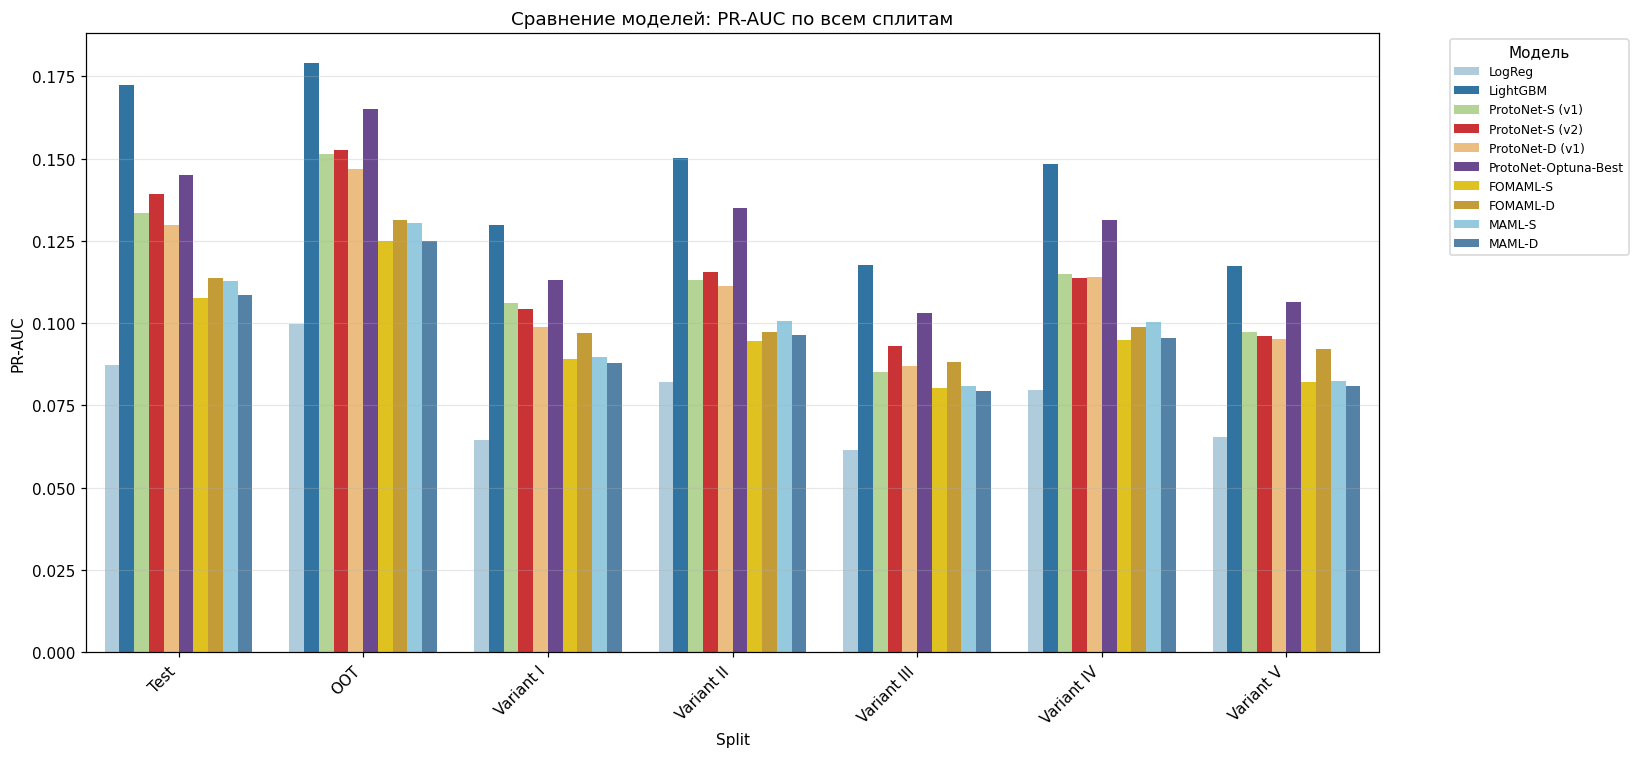

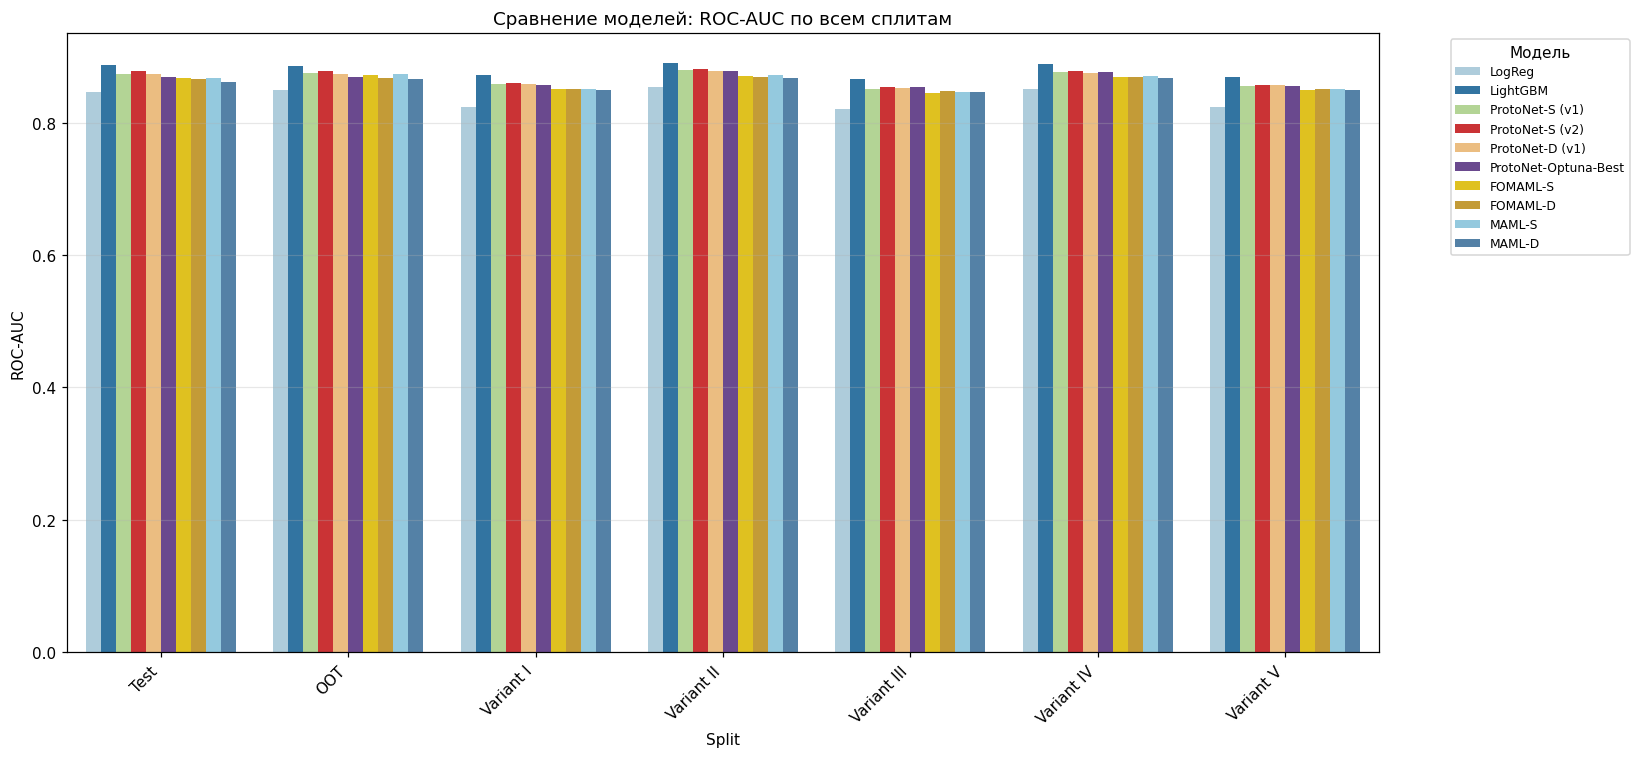

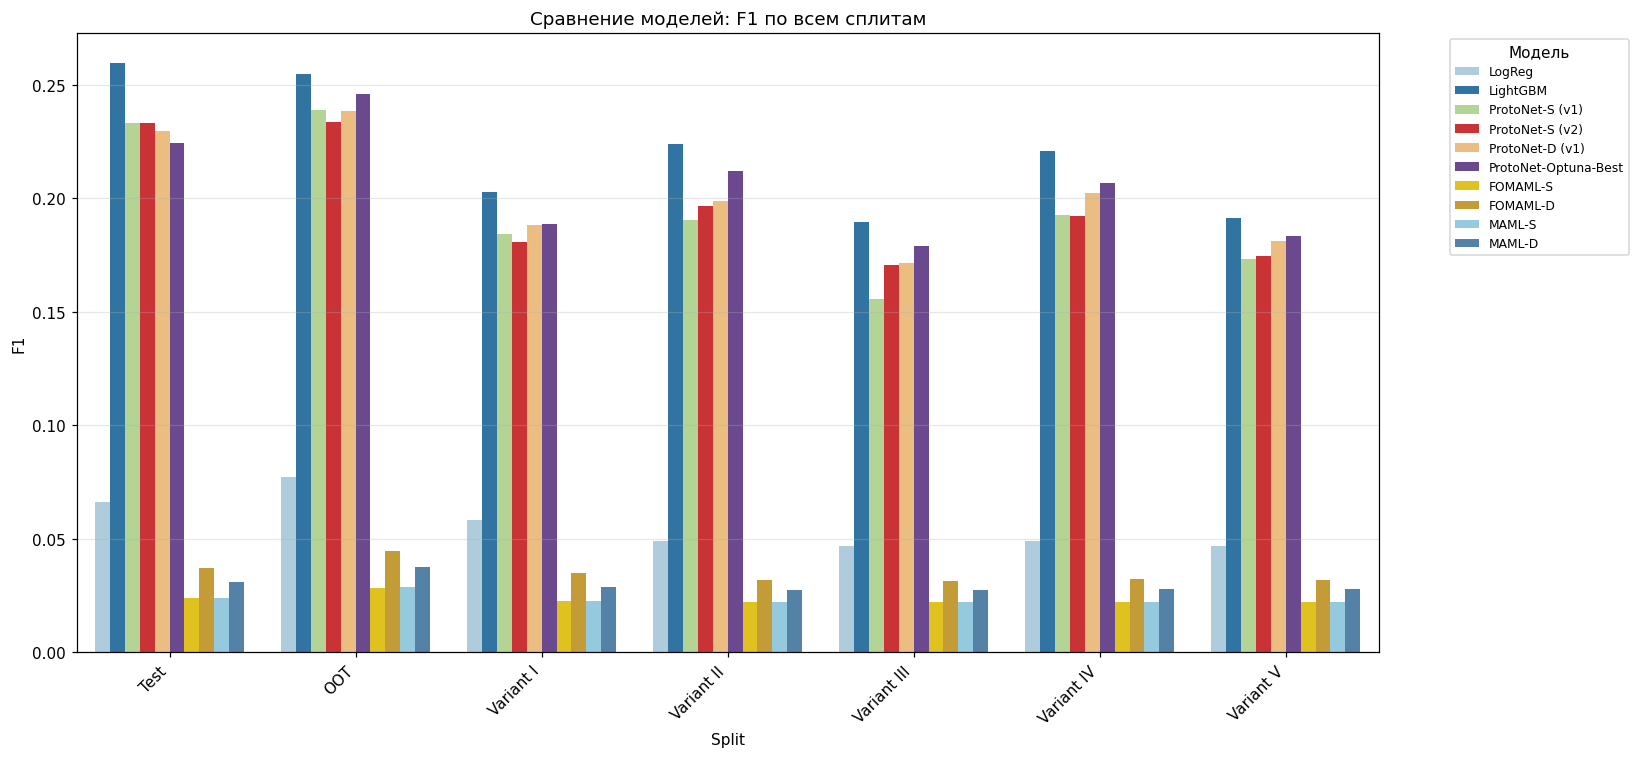

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# __ Визуализация: PR-AUC по Variants ─────────────────────────────────────────
EVAL_SPLITS = ['test', 'OOT', 'I', 'II', 'III', 'IV', 'V']
EVAL_LABELS = ['Test', 'OOT', 'Variant I', 'Variant II', 'Variant III', 'Variant IV', 'Variant V']

pivot_pr = full_df.pivot_table(index='Модель', columns='Сплит',
                                values='PR-AUC', aggfunc='first')
pivot_roc = full_df.pivot_table(index='Модель', columns='Сплит',
                                values='ROC-AUC', aggfunc='first')
pivot_f1 = full_df.pivot_table(index='Модель', columns='Сплит',
                               values='F1', aggfunc='first')

# Models to exclude from visualization as per user request
EXCLUDE_MODELS = [
    'Improved ProtoNet-S (v1)',
    'ProtoNet-D (v2)',
    'ProtoNet-D (v2) Focal',
    'ProtoNet-S (v1) Focal'
]

# Filtered model order for visualization
VIS_MODELS_FOR_PLOTS = [model for model in MODEL_ORDER if model not in EXCLUDE_MODELS]

VIS_COLORS = {
    'LogReg': '#a6cee3',
    'LightGBM': '#1f78b4',
    'ProtoNet-S (v1)': '#b2df8a',
    'ProtoNet-S (v1) Focal': '#33a02c',
    'Improved ProtoNet-S (v1)': '#fb9a99',
    'ProtoNet-S (v2)': '#e31a1c',
    'ProtoNet-D (v1)': '#fdbf6f',
    'ProtoNet-D (v2)': '#ff7f00',
    'ProtoNet-D (v2) Focal': '#cab2d6',
    'ProtoNet-Optuna-Best': '#6a3d9a',
    'FOMAML-S': '#ffd700',
    'FOMAML-D': '#daa520',
    'MAML-S': '#87ceeb',
    'MAML-D': '#4682b4',
}
VIS_STYLES = {
    'LogReg': ':',
    'LightGBM': '--',
    'ProtoNet-S (v1)': '-',
    'ProtoNet-S (v1) Focal': '--',
    'Improved ProtoNet-S (v1)': '-',
    'ProtoNet-S (v2)': '-',
    'ProtoNet-D (v1)': '-',
    'ProtoNet-D (v2)': '--',
    'ProtoNet-D (v2) Focal': '--',
    'ProtoNet-Optuna-Best': '-.',
    'FOMAML-S': '-',
    'FOMAML-D': '-',
    'MAML-S': '-',
    'MAML-D': '-',
}

def plot_comparison_metrics(pivot_table, metric_name, filename_suffix):
    fig, ax = plt.subplots(figsize=(15, 7)) # Increased figure size for more splits

    # Prepare data for bar plot
    plot_data = []
    for model in VIS_MODELS_FOR_PLOTS:
        if model not in pivot_table.index:
            continue
        for i, vs in enumerate(EVAL_SPLITS):
            if vs in pivot_table.columns and pd.notna(pivot_table.loc[model, vs]):
                plot_data.append({
                    'Модель': model,
                    'Сплит': EVAL_LABELS[i],
                    metric_name: pivot_table.loc[model, vs]
                })

    plot_df = pd.DataFrame(plot_data)

    if not plot_df.empty:
        sns.barplot(data=plot_df, x='Сплит', y=metric_name, hue='Модель',
                    palette=VIS_COLORS, ax=ax)

    ax.set_xlabel('Split')
    ax.set_ylabel(metric_name)
    ax.set_title(f'Сравнение моделей: {metric_name} по всем сплитам')
    ax.legend(title='Модель', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'/content/comparison_all_splits_{filename_suffix}_barplot.png', dpi=130)
    plt.show()

# Generate plots for PR-AUC, ROC-AUC, and F1
plot_comparison_metrics(pivot_pr, 'PR-AUC', 'pr_auc')
plot_comparison_metrics(pivot_roc, 'ROC-AUC', 'roc_auc')
plot_comparison_metrics(pivot_f1, 'F1', 'f1')

## Итог

| Артефакт | Путь |
|---|---|
| Чекпоинт FOMAML-S | `/content/fomaml_s_checkpoint.pt` |
| Чекпоинт FOMAML-D | `/content/fomaml_d_checkpoint.pt` |
| Чекпоинт MAML-S   | `/content/maml_s_checkpoint.pt` |
| Чекпоинт MAML-D   | `/content/maml_d_checkpoint.pt` |
| Таблица: все модели | `/content/comparison_all_models.csv` |
| Pivot PR-AUC  | `/content/pivot_pr_auc.csv` |
| Pivot ROC-AUC | `/content/pivot_roc_auc.csv` |
| Pivot F1      | `/content/pivot_f1.csv` |
| Кривые обучения  | `/content/train_curves_all.png` |
| График Variants  | `/content/comparison_variants_pr_auc.png` |

